In [77]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict, List, Annotated, Literal
from pydantic import BaseModel, Field
from __future__ import annotations
from langchain_core.messages import HumanMessage, SystemMessage
import operator
from langgraph.types import Send
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

True

In [78]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )

    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )

    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )

    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )

In [79]:
class Plan(BaseModel):
    blog_title: str 
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]

In [80]:
class State(TypedDict):
    topic: str 
    plan : Plan 
    sections: Annotated[List[str], operator.add]
    final: str

In [81]:
llm = ChatMistralAI(model = "mistral-small-latest", temperature=0)

In [82]:
def orchestractor(state: State):
    planner = llm.with_structured_output(Plan)
    topic = state["topic"]
    plan = planner.invoke([
        SystemMessage(content = (
            "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
        )), 
        HumanMessage(content = f"Topic: {topic}")
    ])

    return {"plan": plan}

In [83]:
def fanout(state: State):
    sends = []
    for task in state["plan"].tasks:
        send_obj = Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"]
            }
        )
        sends.append(send_obj)
    return sends

In [84]:
def worker(payload: State):
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    bullets_text = "\n- " + "\n- ".join(task.bullets)


    section_md = llm.invoke([
        SystemMessage(content = (
            """
            "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n" """
        )),
        HumanMessage(content = (
            f"Blog: {plan.blog_title}\n"
            f"Audience: {plan.audience}"
            f"Tone: {plan.tone}\n"
            f"Topic: {topic}\n\n"
            f"Section: {task.title}\n"
            f"Section type: {task.section_type}\n"
            f"Goal: {task.goal}\n"
            f"Target words: {task.target_words}\n"
            f"Bullets:{bullets_text}\n"
        ))
    ]).content.strip()

    return {"sections": [section_md]}

In [85]:
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

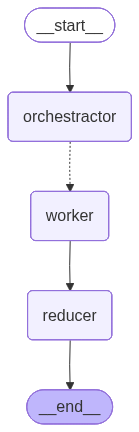

In [86]:
g = StateGraph(State)
g.add_node("orchestractor", orchestractor)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestractor")
g.add_conditional_edges("orchestractor", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [87]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
print(out["final"])

# Demystifying Self-Attention: A Technical Deep Dive for Developers

## Introduction: Why Self-Attention Matters

Self-attention is a mechanism that computes **context-aware representations** for each token in a sequence by relating it to every other token, enabling dynamic focus on relevant parts of the input. Unlike **global attention** (which applies a single transformation to the entire sequence) or **local attention** (which restricts focus to a fixed window), self-attention processes **per-token interactions** across the entire sequence, making it uniquely flexible.

Here’s a minimal comparison between a dense (global) layer and self-attention for sequence processing:

```python
# Dense (global) layer: applies the same transformation to all tokens
import torch.nn as nn
dense = nn.Linear(in_features=512, out_features=512)  # Single weight matrix

# Self-attention: computes token-specific interactions
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super(